In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")

In [5]:
df.shape

(246945, 378)

In [34]:
df.columns.tolist()

['diseases',
 'anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat',
 'throat feels tight',
 'difficulty in swallowing',
 'skin swelling',
 'retention of urine',
 'groin mass',
 'leg pain',
 'hip pain',
 'suprapubic pain',
 'blood in stool',
 'lack of growth',
 'emotional symptoms',
 'elbow weakness',
 'back weakness',
 'pus in sputum',
 'symptoms of the scrotum and testes',
 'swelling of scrotum',
 'pain in testicles',
 'flatulence',
 'pus draining from ear',
 'jaundice',
 'mass in scrotum',
 'white discharge from eye',
 'irritable infant',
 'abusing alcohol',
 'fainting',
 'hostile behavior',
 'drug abuse',
 'sharp abdominal pain

In [8]:
df['diseases'].value_counts().to_dict()

{'cystitis': 1219,
 'nose disorder': 1218,
 'vulvodynia': 1218,
 'complex regional pain syndrome': 1217,
 'spondylosis': 1216,
 'vaginal cyst': 1215,
 'esophagitis': 1215,
 'peripheral nerve disorder': 1215,
 'hypoglycemia': 1215,
 'conjunctivitis due to allergy': 1215,
 'gastrointestinal hemorrhage': 1214,
 'diverticulitis': 1214,
 'acute bronchitis': 1213,
 'infectious gastroenteritis': 1212,
 'fungal infection of the hair': 1212,
 'sprain or strain': 1212,
 'pneumonia': 1212,
 'spontaneous abortion': 1212,
 'gout': 1211,
 'marijuana abuse': 1210,
 'arthritis of the hip': 1210,
 'strep throat': 1210,
 'injury to the arm': 1209,
 'liver disease': 1209,
 'bursitis': 1208,
 'spinal stenosis': 1207,
 'acute pancreatitis': 1207,
 'eczema': 1207,
 'benign prostatic hyperplasia (bph)': 1206,
 'injury to the leg': 1206,
 'noninfectious gastroenteritis': 1206,
 'acute bronchiolitis': 1204,
 'cholecystitis': 1204,
 'anxiety': 1198,
 'obstructive sleep apnea (osa)': 1196,
 'concussion': 1191,
 

In [9]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## visualisation

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

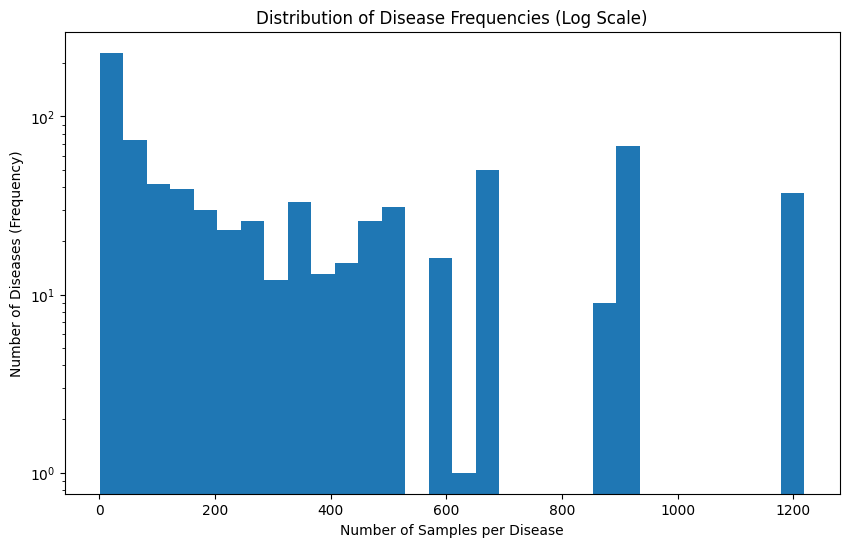

In [33]:
disease_counts = df['diseases'].value_counts()
plt.figure(figsize=(10, 6))
plt.hist(disease_counts, bins=30, log=True) # Use a log scale!
plt.title('Distribution of Disease Frequencies (Log Scale)')
plt.xlabel('Number of Samples per Disease')
plt.ylabel('Number of Diseases (Frequency)')
plt.show()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


In [27]:
# (Assuming 'df' is your loaded DataFrame)

# 1. Look at the first few rows
print("--- First 5 Rows (Head) ---")
print(df.head())

# 2. Check the values in one of your feature columns
# (Using 'neck weakness' from your info)
print("\n--- Value Counts for a Sample Symptom ---")
print(df['neck weakness'].value_counts())

--- First 5 Rows (Head) ---
         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary move

In [36]:
X_train = df.drop('diseases', axis=1)
y_train = df['diseases']

### Frequent Pattern  Mining 

In [41]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(X_train, min_support=0.02, use_colnames=True)

print("--- Discovered Symptom Clusters ---")
print(frequent_itemsets)

/home/adithya-bharadwaj/Desktop/ASBD/venv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- Discovered Symptom Clusters ---
      support                                    itemsets
0    0.086440                       (shortness of breath)
1    0.061001          (depressive or psychotic symptoms)
2    0.039235                   (anxiety and nervousness)
3    0.037871                           (chest tightness)
4    0.025111                       (irregular heartbeat)
..        ...                                         ...
109  0.024135                   (fever, nasal congestion)
110  0.031230                   (cough, nasal congestion)
111  0.020264  (abnormal appearing skin, itching of skin)
112  0.023479      (abnormal appearing skin, skin lesion)
113  0.021280                (skin swelling, skin lesion)

[114 rows x 2 columns]


In [45]:
from mlxtend.frequent_patterns import association_rules

 

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

 
if rules.empty:
    print("No rules found. Try lowering your 'min_threshold' to 0.5 (50%) or 0.3 (30%)")
else:
    print("--- Discovered Association Rules (Confidence >= 70%) ---")
    
    rules_sorted = rules.sort_values(by="lift", ascending=False)
    print(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

--- Discovered Association Rules (Confidence >= 70%) ---
                  antecedents                consequents   support  \
21  (abnormal appearing skin)          (itching of skin)  0.020264   
22          (itching of skin)  (abnormal appearing skin)  0.020264   
23  (abnormal appearing skin)              (skin lesion)  0.023479   
24              (skin lesion)  (abnormal appearing skin)  0.023479   
26              (skin lesion)            (skin swelling)  0.021280   
25            (skin swelling)              (skin lesion)  0.021280   
14  (abnormal appearing skin)            (skin swelling)  0.026467   
15            (skin swelling)  (abnormal appearing skin)  0.026467   
4               (sore throat)         (nasal congestion)  0.021604   
5          (nasal congestion)              (sore throat)  0.021604   
10            (low back pain)                (back pain)  0.021442   
19                    (cough)         (nasal congestion)  0.031230   
20         (nasal congestion)    

## Model Training 

In [46]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

In [47]:
# Let's see the disease counts
disease_counts = df['diseases'].value_counts()

# Set a minimum threshold for samples per disease
MIN_SAMPLES = 20  # You can tune this! 10, 20, or 50 are good starts.

diseases_to_keep = disease_counts[disease_counts >= MIN_SAMPLES].index
df_filtered = df[df['diseases'].isin(diseases_to_keep)].copy()

print(f"Original dataset shape: {df.shape}")
print(f"Filtered dataset shape (diseases with >= {MIN_SAMPLES} samples): {df_filtered.shape}")
print(f"Removed {len(disease_counts) - len(diseases_to_keep)} rare diseases.")

Original dataset shape: (246945, 378)
Filtered dataset shape (diseases with >= 20 samples): (245548, 378)
Removed 166 rare diseases.


In [48]:

print("Starting feature engineering (v2)...")

# --- 1. The Powerful "Skin" Cluster ---
# List all the symptoms from our high-lift rules
skin_symptoms = [
    'abnormal appearing skin', 
    'itching of skin', 
    'skin lesion', 
    'skin swelling'
]

# Create a new feature that is the SUM of how many of these symptoms a patient has (0, 1, 2, 3, or 4)
df_filtered['cluster_skin_syndrome_count'] = df_filtered[skin_symptoms].sum(axis=1)


# --- 2. The "Flu" Cluster ---
flu_symptoms = [
    'sore throat', 
    'nasal congestion', 
    'cough', 
    'fever'
]
# We can use the same count strategy here
df_filtered['cluster_flu_syndrome_count'] = df_filtered[flu_symptoms].sum(axis=1)


# --- 3. The "Abdominal" Cluster ---
abdominal_symptoms = [
    'nausea', 
    'vomiting', 
    'sharp abdominal pain', 
    'burning abdominal pain'
]
df_filtered['cluster_abdominal_syndrome_count'] = df_filtered[abdominal_symptoms].sum(axis=1)


# --- 4. The "Back Pain" Cluster ---
df_filtered['cluster_back_pain'] = df_filtered.apply(
    lambda row: 1 if (row['low back pain'] == 1 and row['back pain'] == 1) else 0,
    axis=1
)

print("Finished feature engineering. New 'count-based' cluster features added.")
print(f"New shape of X data: ({df_filtered.shape[0]}, {df_filtered.shape[1] - 1})")

Starting feature engineering (v2)...
Finished feature engineering. New 'count-based' cluster features added.
New shape of X data: (245548, 381)


In [52]:
# X includes all original symptoms + our new cluster features
X = df_filtered.drop('diseases', axis=1)

# y is our target column
y_str = df_filtered['diseases']

# Encode y from strings to integers
le = LabelEncoder()
y = le.fit_transform(y_str)

# Save the class names for the final report
class_names = le.classes_
print(f"Number of classes after filtering: {len(class_names)}")
# class_names.tolist()

Number of classes after filtering: 607


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,    
    random_state=42,   
    stratify=y         
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (171883, 381)
Testing data shape: (73665, 381)


In [ ]:
print("Training Random Forest model...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # <-- Handles imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model training complete.")

Training Random Forest model...
